In [1]:
import numpy as np
import plotly.express as px

from kaolin.render.camera import Camera, CameraExtrinsics, PinholeIntrinsics
from kaolin.render.mesh import dibr_rasterization
from kaolin.visualize import IpyTurntableVisualizer

from jaxtyping import UInt8, jaxtyped
from beartype import beartype

from src.geometry import NURBS
from src.rendering import Scene, PointLights

In [2]:
import torch

In [3]:
backend = 'nvdiffrast'
device = 'cuda'

height = 540
width = 960

In [4]:
control_points_a = torch.tensor([
    [-1., -1., -1.],
    [-1., -1.,  0.],
    [-1., -1.,  1.],
    [-1.,  0., -1.],
    [-1.,  0.,  0.],
    [-1.,  0.,  1.],
    [-1.,  1., -1.],
    [-1.,  1.,  0.],
    [-1.,  1.,  1.],
    [ 0., -1., -1.],
    [ 0., -1.,  0.],
    [ 0., -1.,  1.],
    [ 0.,  0., -1.],
    [ 0.,  0.,  1.],
    [ 0.,  1., -1.],
    [ 0.,  1.,  0.],
    [ 0.,  1.,  1.],
    [ 1., -1., -1.],
    [ 1., -1.,  0.],
    [ 1., -1.,  1.],
    [ 1.,  0., -1.],
    [ 1.,  0.,  0.],
    [ 1.,  0.,  1.],
    [ 1.,  1., -1.],
    [ 1.,  1.,  0.],
    [ 1.,  1.,  1.]
], dtype=torch.float32)

control_points_b = control_points_a.clone()
control_points_b += 2
control_points_c = control_points_a.clone()
control_points_c[..., 2] += 3

index_map_a = torch.tensor([
    [12, 3, 4, 5, 13],
    [12, 0, 1, 2, 13],
    [12, 9, 10, 11, 13],
    [12, 17, 18, 19, 13],
    [12, 20, 21, 22, 13],
    [12, 23, 24, 25, 13],
    [12, 14, 15, 16, 13],
    [12, 6, 7, 8, 13],
], dtype=torch.int64)

weights_map_a = torch.tensor([
     [1.0000, 0.7071, 1.0000, 0.7071, 1.0000],
     [0.7071, 0.5000, 0.7071, 0.5000, 0.7071],
     [1.0000, 0.7071, 1.0000, 0.7071, 1.0000],
     [0.7071, 0.5000, 0.7071, 0.5000, 0.7071],
     [1.0000, 0.7071, 1.0000, 0.7071, 1.0000],
     [0.7071, 0.5000, 0.7071, 0.5000, 0.7071],
     [1.0000, 0.7071, 1.0000, 0.7071, 1.0000],
     [0.7071, 0.5000, 0.7071, 0.5000, 0.7071]
], dtype=torch.float32)

magn = 1000

sphere_knots_v_a = torch.tensor([magn, 0.0, magn], dtype=torch.float32)
sphere_knots_u_a = torch.tensor([magn, 0.0, magn, 0.0, magn, 0.0, magn], dtype=torch.float32)


color_red = torch.tensor([1.0, 0, 0], dtype=torch.float32)
color_green = torch.tensor([0, 1.0, 0], dtype=torch.float32)
color_blue = torch.tensor([0, 0, 1.0], dtype=torch.float32)

sphere_red = NURBS.from_args(
    control_points_a,
    index_map_a,
    weights_map_a,
    sphere_knots_u_a,
    sphere_knots_v_a,
    color_red,
    roughness=torch.tensor([1.0]),
    metalness=torch.tensor([1.0]),
    degree=2,
    device=device
)

weights_map_b = torch.ones_like(weights_map_a)

sphere_green = NURBS.from_args(
    control_points_b,
    index_map_a,
    weights_map_b,
    sphere_knots_u_a,
    sphere_knots_v_a,
    color_green,
    roughness=torch.tensor([.75]),
    metalness=torch.tensor([0.75]),
    degree=2,
    device=device
)

sphere_blue = NURBS.from_args(
    control_points_c,
    index_map_a,
    weights_map_a,
    sphere_knots_u_a,
    sphere_knots_v_a,
    color_blue,
    roughness=torch.tensor([0.65]),
    metalness=torch.tensor([0.55]),
    degree=2,
    device=device
)

extrinsics = CameraExtrinsics.from_lookat(
    eye=torch.tensor([
        [15.5, 1.0, 10.0],
        [-15, 1.0, -10],
        [15.5, 1.0, -10.0],
        [-25, 10.0, 10]
    ]),
    at=torch.tensor([
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
    ]),
    up=torch.tensor([
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0],
    ]),
    device=device
)
intrinsics = PinholeIntrinsics.from_fov(
    width=width,
    height=height,
    fov=50.0,
    num_cameras=4,
    device=device
)

cameras = Camera(
    extrinsics=extrinsics,
    intrinsics=intrinsics,
)

lights_inte = 150

lights = PointLights(
    positions=torch.tensor([
        [20, 20.0, 20],
        [-20, 20.0, -20],
        [0, -20.0, 0],
    ], dtype=torch.float32, device=device),
    colors=torch.tensor([
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
    ], dtype=torch.float32, device=device),
    intensities=torch.tensor([lights_inte, lights_inte, lights_inte], dtype=torch.float32, device=device),
    sharpness=torch.tensor([15, 15, 15], dtype=torch.float32, device=device)
)

background = torch.tensor([0, 0, 0], dtype=torch.float32, device=device)



In [5]:

control_points_cube = torch.tensor([

    [-1., -1., -1.],                  [-1.,  1., -1.],  # 0,    1,
                     [ 0.,  0., -1.],                   #    2,
    [ 1., -1., -1.],                  [ 1.,  1., -1.],  # 3,    4,

    [-1., -1.,  1.],                  [-1.,  1.,  1.],  # 5,    6,
                     [ 0.,  0.,  1.],                   #    7,
    [ 1., -1.,  1.],                  [ 1.,  1.,  1.],  # 8,    9
], dtype=torch.float32)

control_points_cube *= 0.8
control_points_cube += 2

index_map_cube = torch.tensor([
    [2, 0, 0, 0, 5, 5, 5, 7],
    [2, 1, 1, 1, 6, 6, 6, 7],
    [2, 1, 1, 1, 6, 6, 6, 7],
    [2, 1, 1, 1, 6, 6, 6, 7],
    [2, 4, 4, 4, 9, 9, 9, 7],
    [2, 4, 4, 4, 9, 9, 9, 7],
    [2, 4, 4, 4, 9, 9, 9, 7],
    [2, 3, 3, 3, 8, 8, 8, 7],
    [2, 3, 3, 3, 8, 8, 8, 7],
], dtype=torch.int64, device=device)

weights_map_cube = torch.ones(index_map_cube.shape, dtype=torch.float32, device=device)

magn = 1000
cube_knots_u = torch.tensor([magn, magn, magn, magn, magn, magn, magn, magn], dtype=torch.float32)
cube_knots_v = torch.tensor([magn, magn, magn, magn, magn, magn], dtype=torch.float32)
color_pink = torch.tensor([0.95, 0.2, 0.8], dtype=torch.float32)

cube_green = NURBS.from_args(
    control_points_cube,
    index_map_cube,
    weights_map_cube,
    cube_knots_u,
    cube_knots_v,
    color_pink,
    roughness=torch.tensor([.75]),
    metalness=torch.tensor([0.75]),
    degree=2,
    device=device
)

In [6]:

control_points_min = torch.tensor([

    [-1., -1., -1.],                  [-1.,  1., -1.],  # 0,    1,
                     [ 0.,  0., -1.],                   #    2,
    [ 1., -1., -1.],                  [ 1.,  1., -1.],  # 3,    4,

    [-1., -1.,  1.],                  [-1.,  1.,  1.],  # 5,    6,
                     [ 0.,  0.,  1.],                   #    7,
    [ 1., -1.,  1.],                  [ 1.,  1.,  1.],  # 8,    9
], dtype=torch.float32)


index_map_min = torch.tensor([
    [2, 0, 5, 7],
    [2, 1, 6, 7],
    [2, 3, 8, 7],
], dtype=torch.int64, device=device)

weights_map_min = torch.ones(index_map_min.shape, dtype=torch.float32, device=device)

magn = 1000
min_knots_u = torch.tensor([magn, magn], dtype=torch.float32)
min_knots_v = torch.tensor([magn, magn], dtype=torch.float32)
color_pink = torch.tensor([0.95, 0.2, 0.8], dtype=torch.float32)

min_green = NURBS.from_args(
    control_points_min,
    index_map_min,
    weights_map_min,
    min_knots_u,
    min_knots_v,
    color_pink,
    roughness=torch.tensor([.75]),
    metalness=torch.tensor([0.75]),
    degree=2,
    device=device
)

In [7]:
list_nurbs = [sphere_red, sphere_blue, sphere_green]
scene = Scene(list_nurbs, cameras, lights, background)

discretization_u = torch.linspace(0.0, 1.0, 100, device=device)
discretization_v = torch.linspace(0.0, 1.0, 100, device=device)
cameras_idx = torch.tensor([0, 1, 2, 3], dtype=torch.int32)

In [8]:
img, depth, rast_out = scene.forward(discretization_u, discretization_v, cameras_idx)
img.shape

torch.Size([4, 540, 960, 3])

In [9]:
img_c = img[3].detach().cpu()
fig = px.imshow(img_c)
fig.show()

In [10]:
import imageio
import os

RESULTS_DIR = "optimization_test"
os.makedirs(RESULTS_DIR, exist_ok=True)

camera_idx = torch.tensor([0, 1, 2, 3], dtype=torch.int32, device=scene.device)

with torch.no_grad():
    target_img, target_depth, target_mask = scene.forward(discretization_u, discretization_v, camera_idx)
    target_img_display = target_img[0].detach().cpu().numpy()

    fig = px.imshow(target_img_display)
    fig.show()


In [11]:
noise = 0.2
control_points_a_train = control_points_a + (torch.rand_like(control_points_a) - 0.5) * noise
control_points_b_train = control_points_b + (torch.rand_like(control_points_b) - 0.5) * noise
control_points_c_train = control_points_c + (torch.rand_like(control_points_c) - 0.5) * noise

knot_u_a_train = torch.rand_like(sphere_knots_u_a, device=device)
knot_u_b_train = torch.rand_like(sphere_knots_u_a, device=device)
knot_u_c_train = torch.rand_like(sphere_knots_u_a, device=device)

knot_v_a_train = torch.rand_like(sphere_knots_v_a, device=device)
knot_v_b_train = torch.rand_like(sphere_knots_v_a, device=device)
knot_v_c_train = torch.rand_like(sphere_knots_v_a, device=device)

weights_map_a_train = torch.rand_like(weights_map_a, device=device)
weights_map_b_train = torch.rand_like(weights_map_a, device=device)
weights_map_c_train = torch.rand_like(weights_map_a, device=device)

metalness_a_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)
metalness_b_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)
metalness_c_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)

roughness_a_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)
roughness_b_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)
roughness_c_train = torch.tensor([1.0], device=device) #torch.rand(1, device=device)

color_red_train = torch.rand_like(color_red)
color_blue_train = torch.rand_like(color_blue)
color_green_train = torch.rand_like(color_green)


sphere_red_train = NURBS.from_args(
    control_points_a_train,
    index_map_a,
    weights_map_a_train,
    knot_u_a_train,
    knot_v_a_train,
    color_red_train,
    roughness=torch.tensor([1.0]),
    metalness=torch.tensor([1.0]),
    degree=2,
    device=device
)

sphere_green_train = NURBS.from_args(
    control_points_b_train,
    index_map_a,
    weights_map_b_train,
    knot_u_b_train,
    knot_v_b_train,
    color_green_train,
    roughness=torch.tensor([.75]),
    metalness=torch.tensor([0.75]),
    degree=2,
    device=device
)

sphere_blue_train = NURBS.from_args(
    control_points_c_train,
    index_map_a,
    weights_map_c_train,
    knot_u_c_train,
    knot_v_c_train,
    color_blue_train,
    roughness=torch.tensor([0.65]),
    metalness=torch.tensor([0.55]),
    degree=2,
    device=device
)


list_nurbs_train = [sphere_red_train, sphere_blue_train, sphere_green_train]
scene_train = Scene(list_nurbs_train, cameras, lights, background)

In [12]:
pred_img, pred_depth, pred_mask = scene_train.forward(discretization_u, discretization_v, cameras_idx)

In [13]:
img = pred_img[0].detach().cpu().numpy()
final_img = img
fig = px.imshow(final_img)
fig.show()

In [14]:
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd

class GradientTracker:
    def __init__(self):
        self.history = defaultdict(lambda: {'grad_norm': [], 'param_norm': [], 'update_ratio': []})

    def track(self, model, optimizer, iteration):
        """Appeler après backward() mais AVANT optimizer.step()"""

        for name, param in model.named_parameters():
            if param.grad is None:
                continue

            grad_norm = param.grad.norm().item()
            param_norm = param.norm().item()

            # Ratio critique : update / param
            # Si < 1e-3, les paramètres ne bougent pas significativement
            lr = self._get_lr(optimizer, param)
            update_norm = (lr * param.grad).norm().item()
            update_ratio = update_norm / (param_norm + 1e-10)

            self.history[name]['grad_norm'].append(grad_norm)
            self.history[name]['param_norm'].append(param_norm)
            self.history[name]['update_ratio'].append(update_ratio)

            # Print en temps réel
            if iteration % 100 == 0:
                print(f"{name:40s} | grad_norm: {grad_norm:8.2e} | "
                      f"update_ratio: {update_ratio:8.2e} | "
                      f"lr: {lr:8.2e}")

    def _get_lr(self, optimizer, param):
        """Trouve le learning rate pour ce paramètre"""
        for param_group in optimizer.param_groups:
            if any(p is param for p in param_group['params']):
                return param_group['lr']
        return 0.0

    def plot(self, param_names=None, export_csv=True, smooth_window=50):
        """Visualise l'évolution et génère un CSV ultra-léger pour l'intégration Typst"""
        if param_names is None:
            param_names = list(self.history.keys())[:3]  # Top 3

        fig, axes = plt.subplots(3, 1, figsize=(12, 10))

        # Dictionnaire qui va accumuler les données sous format tabulaire "large"
        csv_data = {}

        for name in param_names:
            if name not in self.history:
                continue
            data = self.history[name]

            # 1. Tracé Matplotlib classique
            axes[0].semilogy(data['grad_norm'], label=name)
            axes[1].semilogy(data['param_norm'], label=name)
            axes[2].semilogy(data['update_ratio'], label=name)

            # 2. Préparation pour le CSV
            if export_csv:
                # On initialise l'axe des itérations si ce n'est pas fait
                if 'iteration' not in csv_data:
                    csv_data['iteration'] = list(range(len(data['grad_norm'])))

                # On stocke chaque métrique avec le nom du paramètre pour des colonnes propres
                csv_data[f'{name}_grad'] = data['grad_norm']
                csv_data[f'{name}_param'] = data['param_norm']
                csv_data[f'{name}_update'] = data['update_ratio']

        # --- L'EXPORT OPTIMISÉ ---
        if export_csv and csv_data:
            df = pd.DataFrame(csv_data)

            # Sous-échantillonnage intelligent : on regroupe par blocs et on fait la moyenne
            # Cela élimine le bruit stochastique et rend le fichier digeste pour Typst
            df_typst = df.groupby(df.index // smooth_window).mean()

            # On recrée une colonne d'itération correcte après le regroupement
            df_typst['iteration'] = df_typst.index * smooth_window

            # Export sans l'index de pandas
            csv_filename = 'gradient_tracking_typst.csv'
            df_typst.to_csv(csv_filename, index=False)
            print(f"✅ Export réussi : {csv_filename} ({len(df_typst)} points lissés générés)")

        # --- CONFIGURATION DES AXES MATPLOTLIB ---
        axes[0].set_ylabel('Gradient Norm')
        axes[0].legend()
        axes[0].axhline(1e-5, color='r', linestyle='--', alpha=0.3, label='Danger zone')

        axes[1].set_ylabel('Parameter Norm')
        axes[1].legend()

        axes[2].set_ylabel('Update Ratio (update/param)')
        axes[2].axhline(1e-3, color='r', linestyle='--', alpha=0.3, label='Minimum viable')
        axes[2].legend()
        axes[2].set_xlabel('Iteration')

        plt.tight_layout()
        plt.savefig('gradient_tracking.png', dpi=150)
        plt.show()

    # def plot(self, param_names=None):
    #     """Visualise l'évolution"""
    #     if param_names is None:
    #         param_names = list(self.history.keys())[:3]  # Top 3
    #
    #     fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    #
    #     for name in param_names:
    #         if name not in self.history:
    #             continue
    #         data = self.history[name]
    #
    #         axes[0].semilogy(data['grad_norm'], label=name)
    #         axes[1].semilogy(data['param_norm'], label=name)
    #         axes[2].semilogy(data['update_ratio'], label=name)
    #
    #     axes[0].set_ylabel('Gradient Norm')
    #     axes[0].legend()
    #     axes[0].axhline(1e-5, color='r', linestyle='--', alpha=0.3, label='Danger zone')
    #
    #     axes[1].set_ylabel('Parameter Norm')
    #     axes[1].legend()
    #
    #     axes[2].set_ylabel('Update Ratio (update/param)')
    #     axes[2].axhline(1e-3, color='r', linestyle='--', alpha=0.3, label='Minimum viable')
    #     axes[2].legend()
    #     axes[2].set_xlabel('Iteration')
    #
    #     plt.tight_layout()
    #     plt.savefig('gradient_tracking.png', dpi=150)
    #     plt.show()

nurbs.0.control_points                   | grad_norm: 2.42e-01 | update_ratio: 3.28e-05 | lr: 1.00e-03
nurbs.0.weights_map                      | grad_norm: 8.68e-01 | update_ratio: 2.66e-07 | lr: 1.00e-06
nurbs.0.knot_deltas_u                    | grad_norm: 6.88e-02 | update_ratio: 1.93e-04 | lr: 5.00e-03
nurbs.0.knot_deltas_v                    | grad_norm: 2.70e-05 | update_ratio: 1.12e-07 | lr: 5.00e-03
nurbs.0.albedo_rgb                       | grad_norm: 1.74e-03 | update_ratio: 2.50e-06 | lr: 1.00e-03
nurbs.1.control_points                   | grad_norm: 2.70e-04 | update_ratio: 1.59e-08 | lr: 1.00e-03
nurbs.1.weights_map                      | grad_norm: 2.84e-04 | update_ratio: 7.63e-11 | lr: 1.00e-06
nurbs.1.knot_deltas_u                    | grad_norm: 1.00e-04 | update_ratio: 3.56e-07 | lr: 5.00e-03
nurbs.1.knot_deltas_v                    | grad_norm: 4.94e-05 | update_ratio: 1.80e-07 | lr: 5.00e-03
nurbs.1.albedo_rgb                       | grad_norm: 1.31e-03 | update_r

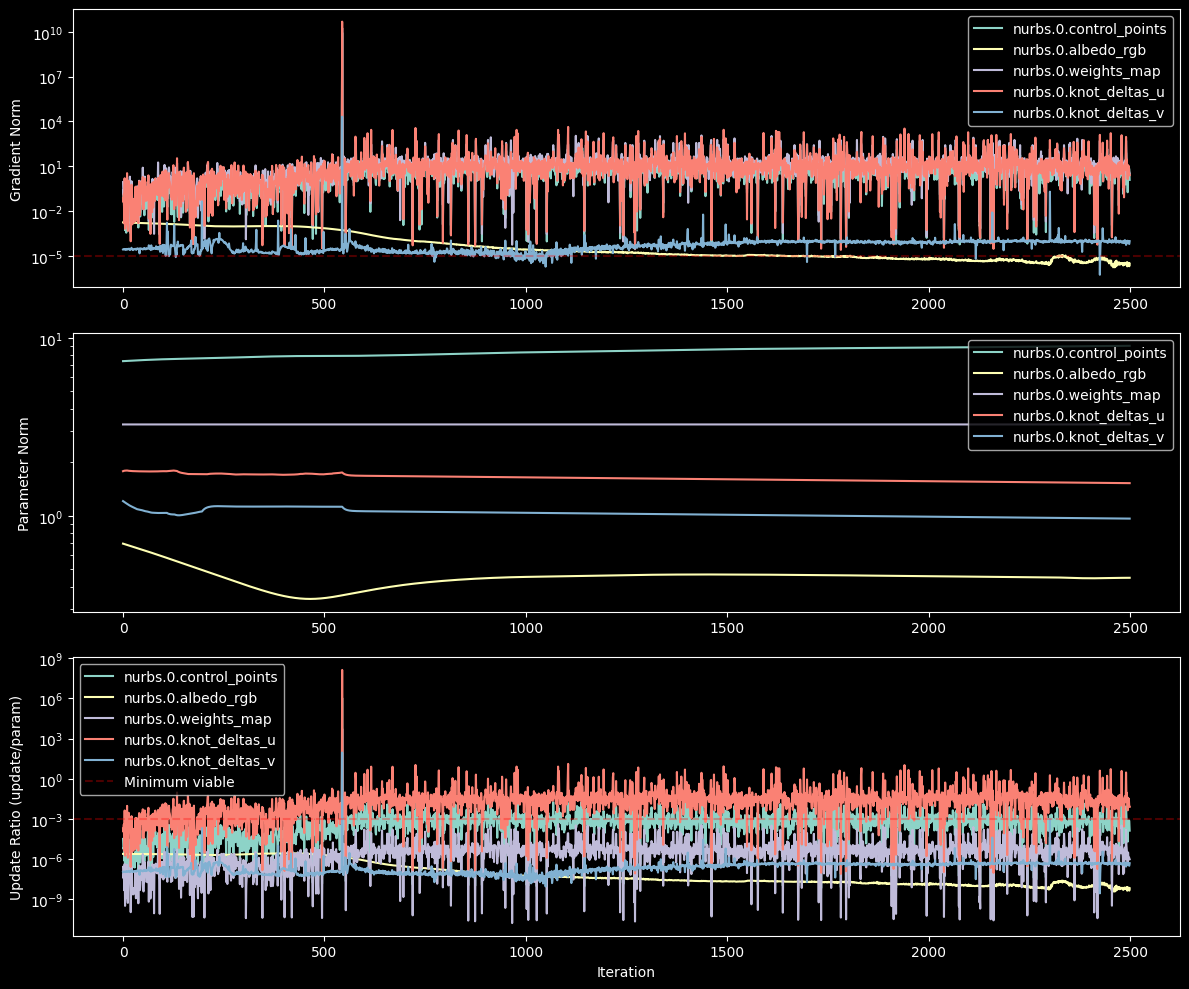

In [16]:
import os
import torch
import imageio
import numpy as np
import torchvision.transforms.functional as TF

# --- 1. OPTIMIZER SETUP ---
optimizer = torch.optim.AdamW([
    {'params': [n.control_points for n in scene_train.nurbs],   'lr': 1e-3},
    {'params': [n.weights_map for n in scene_train.nurbs],      'lr': 1e-6},
    {'params': [n.knot_deltas_u for n in scene_train.nurbs],    'lr': 5e-3},
    {'params': [n.knot_deltas_v for n in scene_train.nurbs],    'lr': 5e-3},
    {'params': [n.albedo_rgb for n in scene_train.nurbs],       'lr': 1e-3},
])

frames = []
iterations = 2500
tracker = GradientTracker()

# --- 2. HYPERPARAMETERS ---
lambda_img = 1.0
lambda_depth = 0.1
blur_decay_iters = iterations * 0.5

for it in range(iterations):
    optimizer.zero_grad()


    pred_img, pred_depth, pred_mask = scene_train.forward(discretization_u, discretization_v, camera_idx)

    valid_mask = (pred_mask > 0.5).float() * (target_mask > 0.5).float()
    depth_diff = torch.abs(pred_depth - target_depth)
    depth_loss = (depth_diff * valid_mask).sum() / (valid_mask.sum() + 1e-8)


    current_sigma = max(0.1, 3.0 * (1.0 - (it / blur_decay_iters)))

    if current_sigma > 0.2:
        kernel_s = int(current_sigma * 3)
        kernel_s = kernel_s if kernel_s % 2 == 1 else kernel_s + 1


        pred_img_b = TF.gaussian_blur(pred_img.permute(0, 3, 1, 2), kernel_size=kernel_s, sigma=current_sigma)
        target_img_b = TF.gaussian_blur(target_img.permute(0, 3, 1, 2), kernel_size=kernel_s, sigma=current_sigma)
    else:
        pred_img_b = pred_img.permute(0, 3, 1, 2)
        target_img_b = target_img.permute(0, 3, 1, 2)


    img_loss = torch.nn.functional.huber_loss(pred_img_b, target_img_b, delta=0.1)

    loss = img_loss# (img_loss * lambda_img) + (depth_loss * lambda_depth)
    loss.backward()

    tracker.track(scene_train, optimizer, it)
    optimizer.step()

    if it % 20 == 0:
        print(f"Iter {it:03d} | Total: {loss.item():.4f} | Img: {img_loss.item():.4f} | Depth: {depth_loss.item():.4f} | Blur: {current_sigma:.2f}")

        with torch.no_grad():
            blended = (pred_img * 0.7 + target_img * 0.3) * 255.0
            blended_np = torch.clamp(blended, 0, 255).byte().cpu().numpy()


            row1 = np.concatenate([blended_np[0], blended_np[1]], axis=1)
            row2 = np.concatenate([blended_np[2], blended_np[3]], axis=1)
            grid_image = np.concatenate([row1, row2], axis=0)

            frames.append(grid_image)


gif_path = os.path.join(RESULTS_DIR, "training_progress.gif")
imageio.mimsave(gif_path, frames, fps=15)
tracker.plot(['nurbs.0.control_points', 'nurbs.0.albedo_rgb', 'nurbs.0.weights_map', 'nurbs.0.knot_deltas_u', 'nurbs.0.knot_deltas_v'])

In [ ]:
pred_img, pred_depth, pred_mask = scene_train.forward(discretization_u, discretization_v, cameras_idx)
img = pred_img[0].detach().cpu().numpy()
final_img = img
fig = px.imshow(final_img)
fig.show()

In [ ]:
stop

In [ ]:
df = pd.read_csv('gradient_tracking_typst.csv')
df

In [ ]:
df = df[['nurbs.0.albedo_rgb_grad', 'nurbs.0.control_points_grad', 'nurbs.0.knot_deltas_u_grad', 'nurbs.0.knot_deltas_v_grad', 'nurbs.0.weights_map_grad']]
df

In [ ]:
plt.plot(df)

In [ ]:
df.to_csv('data_training.csv')

In [21]:
import os
import numpy as np
from PIL import Image

def extract_poster_timeline(gif_path, output_dir="poster_frames", num_frames=4):
    """
    Extrait N frames parfaitement réparties d'un GIF pour créer une frise chronologique.
    """
    # 1. Création du dossier de destination s'il n'existe pas
    os.makedirs(output_dir, exist_ok=True)

    try:
        with Image.open(gif_path) as img:
            total_frames = img.n_frames
            print(f"🎬 GIF détecté avec {total_frames} frames.")

            # 2. Calcul des indices équidistants (ex: début, 1/3, 2/3, fin)
            indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

            indices = np.array([0, total_frames-1, int(total_frames * 0.25), int(total_frames * 0.75)])

            # 3. Extraction et sauvegarde de la plus haute qualité
            for i, frame_idx in enumerate(indices):
                img.seek(frame_idx)

                # Astuce Pro : Convertir en RGB pur pour éviter les artefacts
                # de la palette de couleurs indexée (typique des GIFs)
                rgb_img = img.convert('RGB')

                # Format du nom : frame_1_iter_0.png
                output_path = os.path.join(output_dir, f"timeline_{i+1}_step_{frame_idx}.png")
                rgb_img.save(output_path, format="PNG", quality=100)

                print(f"✅ Image {i+1}/{num_frames} sauvegardée : {output_path}")

    except Exception as e:
        print(f"❌ Erreur lors de la lecture du GIF : {e}")

# Utilisation :
# Remplace 'ton_rendu.gif' par le nom de ton fichier.
# On demande 4 images pour faire une belle grille 1x4 ou 2x2 dans Typst.
extract_poster_timeline("optimization_test/training_progress.gif", output_dir="poster_frames_miss", num_frames=4)

🎬 GIF détecté avec 125 frames.
✅ Image 1/4 sauvegardée : poster_frames_miss\timeline_1_step_0.png
✅ Image 2/4 sauvegardée : poster_frames_miss\timeline_2_step_124.png
✅ Image 3/4 sauvegardée : poster_frames_miss\timeline_3_step_31.png
✅ Image 4/4 sauvegardée : poster_frames_miss\timeline_4_step_93.png


In [ ]:
@jaxtyped(typechecker=beartype)
def render(
    scene: list[NURBS],
    cameras: list[Camera],
    H: int = 1080,
    W: int = 1920
): #-> Float32[torch.Tensor, "Cam H W 3"]:
    verts_vector = []
    faces_vector = []
    colors_vector = []
    offset = 0

    discretization_u = torch.linspace(0, 1, 20)
    discretization_v = torch.linspace(0, 1, 20)

    for nurbs in scene:
        verts_k, faces_k = nurbs(
            discretization_u,
            discretization_v
        )

        verts_vector.append(verts_k)
        faces_vector.append(faces_k + offset)
        colors_vector.append(nurbs.albedo_rgb.expand(faces_k.shape + nurbs.albedo_rgb.shape))

        offset += verts_k.shape[0]

    verts_vector = torch.cat(verts_vector, dim=0)
    faces_vector = torch.cat(faces_vector, dim=0)
    colors_vector = torch.cat(colors_vector, dim=0)

    projected_verts = []
    cameras_rotation = []

    for camera in cameras:
        projected_verts.append(camera.transform(verts_vector))
        cameras_rotation.append(camera.extrinsics.R)

    projected_verts = torch.stack(projected_verts)
    cameras_rotation = torch.cat(cameras_rotation, dim=0)

    e1 = verts_vector[faces_vector[..., 1]] - verts_vector[faces_vector[..., 0]]
    e2 = verts_vector[faces_vector[..., 2]] - verts_vector[faces_vector[..., 0]]

    normals = torch.cross(e1, e2, dim=-1)
    normals = torch.nn.functional.normalize(normals, dim=-1)

    face_normals = (cameras_rotation @ normals.T).mT

    face_vertices_z = projected_verts[..., faces_vector, 2]
    face_vertices_image = projected_verts[..., faces_vector, :2]
    face_features = colors_vector.unsqueeze(0).expand(len(cameras), -1, -1, -1).contiguous()
    face_normals_z = face_normals[..., 2]

    print(f"{face_vertices_z.shape} \n"
          f"{face_vertices_image.shape} \n"
          f"{face_features.shape} \n"
          f"{face_normals_z.shape}")

    rendered_features, rendered_soft_mask, rendered_face_idx = dibr_rasterization(H, W, face_vertices_z, face_vertices_image, face_features, face_normals_z, rast_backend=backend)

    return rendered_features

In [ ]:
a = render(list_nurbs, [cameras[0]], H=height, W=width)
img = a[0].detach().cpu()
img = img.byte()
fig = px.imshow(img)
fig.show()

In [ ]:
@torch.no_grad()
def visualize(
        scene: list[NURBS],
        height: int = 512,
        width: int = 512
) -> None:

    def render_visualize(camera: Camera) -> UInt8[torch.Tensor, "H W 3"]:
        face_normals = (camera.extrinsics.R @ normals.T).mT

        projected_verts = camera.transform(verts_vector)

        face_vertices_z = projected_verts[..., faces_vector, 2].unsqueeze(0)
        face_vertices_image = projected_verts[..., faces_vector, :2].unsqueeze(0)
        face_normals_z = face_normals[..., 2]

        rendered_features, rendered_soft_mask, rendered_face_idx = dibr_rasterization(height, width, face_vertices_z, face_vertices_image, face_features, face_normals_z, rast_backend=backend)

        return rendered_features[0].byte()

    verts_vector = []
    faces_vector = []
    colors_vector = []
    offset = 0

    discretization_u = torch.linspace(0, 1, 80)
    discretization_v = torch.linspace(0, 1, 80)

    for nurbs in scene:
        verts_k, faces_k = nurbs(
            discretization_u,
            discretization_v
        )

        verts_vector.append(verts_k)
        faces_vector.append(faces_k + offset)
        colors_vector.append(nurbs.albedo_rgb.expand(faces_k.shape + nurbs.albedo_rgb.shape))

        offset += verts_k.shape[0]

    verts_vector = torch.cat(verts_vector, dim=0)
    faces_vector = torch.cat(faces_vector, dim=0)
    colors_vector = torch.cat(colors_vector, dim=0)


    e1 = verts_vector[faces_vector[..., 1]] - verts_vector[faces_vector[..., 0]]
    e2 = verts_vector[faces_vector[..., 2]] - verts_vector[faces_vector[..., 0]]

    normals = torch.cross(e1, e2, dim=-1)
    normals = torch.nn.functional.normalize(normals, dim=-1)

    face_features = colors_vector.unsqueeze(0).expand(1, -1, -1, -1).contiguous()

    camera = Camera.from_args(
        eye=torch.tensor([10.0, 0.0, 0.0]),
        at=torch.tensor([1.0, 1.0, 0.0]),
        up=torch.tensor([0.0, 1.0, 0.0]),
        fov=30 * np.pi / 180,
        width=width, height=height,
        near=1e-2, far=1e2,
        dtype=torch.float32,
        device='cuda'
    )

    turnable_visualizer = IpyTurntableVisualizer(
        height=height,
        width=width,
        camera=camera,
        render=render_visualize
    )

    turnable_visualizer.show()




In [ ]:
visualize(list_nurbs)